<a href="https://colab.research.google.com/github/nehalnady/DM_Project/blob/main/DM_Regression_Task_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from imblearn.over_sampling import RandomOverSampler, SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    IMBLEARN_AVAILABLE = True
    IMBLEARN_MESSAGE = "imbalanced-learn is available."
except Exception as exc:
    IMBLEARN_AVAILABLE = False
    IMBLEARN_MESSAGE = f"imbalanced-learn is not available: {exc}"

df = pd.read_csv("/content/vehicles.csv", engine="python", on_bad_lines="skip")
df.columns = df.columns.str.strip().str.lower()

print("Step 0 - Data loaded")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values before preprocessing:")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False).head(15))
print("\nImbalance tool check:", IMBLEARN_MESSAGE)


Step 0 - Data loaded
Dataset shape: (11352, 26)
Columns: ['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'vin', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']

First 5 rows:
           id                                                url  \
0  7222695916  https://prescott.craigslist.org/cto/d/prescott...   
1  7218891961  https://fayar.craigslist.org/ctd/d/bentonville...   
2  7221797935  https://keys.craigslist.org/cto/d/summerland-k...   
3  7222270760  https://worcester.craigslist.org/cto/d/west-br...   
4  7210384030  https://greensboro.craigslist.org/cto/d/trinit...   

                   region                         region_url  price  year  \
0                prescott    https://prescott.craigslist.org   6000   NaN   
1            fayetteville       https://fayar.craigslist.org  11900   NaN   
2    

In [2]:
work_df = df.copy()

print("Step 1 - Basic cleaning")
before_rows = len(work_df)
work_df = work_df.drop_duplicates().reset_index(drop=True)
print(f"Removed duplicates: {before_rows - len(work_df)}")
print(f"Rows after duplicate removal: {len(work_df)}")

drop_cols = ["id", "url", "region_url", "image_url", "description", "vin", "posting_date", "county"]
existing_drop_cols = [col for col in drop_cols if col in work_df.columns]
work_df = work_df.drop(columns=existing_drop_cols)
print("Dropped columns:", existing_drop_cols)
print("Shape after dropping columns:", work_df.shape)

target_col = "price"
if target_col not in work_df.columns:
    raise ValueError("The target column 'price' was not found in the dataset.")

numeric_candidates = ["year", "odometer", "lat", "long", target_col]
for col in numeric_candidates:
    if col in work_df.columns:
        work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

if "year" in work_df.columns:
    current_year = pd.Timestamp.today().year
    work_df["car_age"] = current_year - work_df["year"]
    work_df = work_df.drop(columns=["year"])
    print("Created new feature: car_age")

X_raw = work_df.drop(columns=[target_col]).copy()
y = work_df[target_col].copy()

numeric_feature_cols = X_raw.select_dtypes(include=["number"]).columns.tolist()
categorical_feature_cols = X_raw.select_dtypes(include=["object"]).columns.tolist()

preferred_label_cols = [
    "manufacturer", "condition", "cylinders", "fuel", "title_status",
    "transmission", "drive", "size", "type", "paint_color", "state"
]
label_encode_cols = [col for col in preferred_label_cols if col in categorical_feature_cols]
onehot_cols = [col for col in categorical_feature_cols if col not in label_encode_cols]

if not onehot_cols and label_encode_cols:
    moved_col = label_encode_cols.pop()
    onehot_cols.append(moved_col)

if not label_encode_cols and onehot_cols:
    moved_col = onehot_cols.pop()
    label_encode_cols.append(moved_col)

print("\nStep 2 - Column groups")
print("Numeric columns:", numeric_feature_cols)
print("Label encoder columns:", label_encode_cols)
print("One-hot encoder columns:", onehot_cols)

num_imputer = SimpleImputer(strategy="median")
X_num = pd.DataFrame(
    num_imputer.fit_transform(X_raw[numeric_feature_cols]),
    columns=numeric_feature_cols,
    index=X_raw.index
)

cat_imputer = SimpleImputer(strategy="most_frequent")

if label_encode_cols:
    X_label = pd.DataFrame(
        cat_imputer.fit_transform(X_raw[label_encode_cols]),
        columns=label_encode_cols,
        index=X_raw.index
    )
    label_encoders = {}
    for col in label_encode_cols:
        encoder = LabelEncoder()
        X_label[col] = encoder.fit_transform(X_label[col].astype(str))
        label_encoders[col] = encoder
else:
    X_label = pd.DataFrame(index=X_raw.index)
    label_encoders = {}

if onehot_cols:
    X_onehot_input = pd.DataFrame(
        cat_imputer.fit_transform(X_raw[onehot_cols]),
        columns=onehot_cols,
        index=X_raw.index
    )
    try:
        onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)
    X_onehot = pd.DataFrame(
        onehot_encoder.fit_transform(X_onehot_input),
        columns=onehot_encoder.get_feature_names_out(onehot_cols),
        index=X_raw.index
    )
else:
    X_onehot = pd.DataFrame(index=X_raw.index)

X_processed = pd.concat([X_num, X_label, X_onehot], axis=1)
y_imputer = SimpleImputer(strategy="median")
y = pd.Series(y_imputer.fit_transform(y.to_frame()).ravel(), name=target_col, index=y.index)

print("\nStep 3 - After SimpleImputer and encoding")
print("Processed feature shape:", X_processed.shape)
print("Remaining missing values in X:", int(X_processed.isnull().sum().sum()))
print("Remaining missing values in y:", int(y.isnull().sum()))
print("\nProcessed feature preview:")
print(X_processed.head())

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

X_standardized = pd.DataFrame(
    standard_scaler.fit_transform(X_processed),
    columns=X_processed.columns,
    index=X_processed.index
)
X_normalized = pd.DataFrame(
    minmax_scaler.fit_transform(X_processed),
    columns=X_processed.columns,
    index=X_processed.index
)

preview_cols = X_processed.columns[:min(5, len(X_processed.columns))]
print("\nStep 4 - Feature scaling")
print("Standardized data preview:")
print(X_standardized.loc[:, preview_cols].head())
print("\nNormalized data preview:")
print(X_normalized.loc[:, preview_cols].head())


Step 1 - Basic cleaning
Removed duplicates: 0
Rows after duplicate removal: 11352
Dropped columns: ['id', 'url', 'region_url', 'image_url', 'description', 'vin', 'posting_date', 'county']
Shape after dropping columns: (11352, 18)
Created new feature: car_age

Step 2 - Column groups
Numeric columns: ['odometer', 'lat', 'long', 'car_age']
Label encoder columns: ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state']
One-hot encoder columns: ['region', 'model']

Step 3 - After SimpleImputer and encoding
Processed feature shape: (11352, 2975)
Remaining missing values in X: 0
Remaining missing values in y: 0

Processed feature preview:
   odometer    lat        long  car_age  manufacturer  condition  cylinders  \
0   68696.0  34.57 -111.666438     12.0            12          2          5   
1   68696.0  34.57 -111.666438     12.0            12          2          5   
2   68696.0  34.57 -111.666438     12.0         

In [3]:
X_train_std, X_test_std, y_train, y_test = train_test_split(
    X_standardized, y, test_size=0.2, random_state=42
)
X_train_norm, X_test_norm, _, _ = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)

print("Step 5 - Train/test split")
print("X_train_std:", X_train_std.shape)
print("X_test_std :", X_test_std.shape)
print("y_train    :", y_train.shape)
print("y_test     :", y_test.shape)

X_train_balanced = X_train_std.copy()
y_train_balanced = y_train.copy()
resampling_method = "No resampling applied"

y_train_bins = pd.cut(y_train, bins=5, labels=False, include_lowest=True)
bin_counts = y_train_bins.value_counts().sort_index()
bin_counts = bin_counts[bin_counts > 0]
imbalance_ratio = float(bin_counts.max() / bin_counts.min()) if len(bin_counts) > 1 else 1.0

print("\nStep 6 - Imbalance check on the training target")
print("Target bin counts:")
print(bin_counts)
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")

if IMBLEARN_AVAILABLE and len(bin_counts) > 1 and imbalance_ratio > 1.5:
    bin_medians = y_train.groupby(y_train_bins).median()

    if bin_counts.min() >= 6 and imbalance_ratio >= 3:
        sampler = SMOTE(random_state=42, k_neighbors=min(5, int(bin_counts.min()) - 1))
        resampling_method = "SMOTE on binned target"
    elif imbalance_ratio > 2:
        sampler = RandomOverSampler(random_state=42)
        resampling_method = "RandomOverSampler on binned target"
    else:
        sampler = RandomUnderSampler(random_state=42)
        resampling_method = "RandomUnderSampler on binned target"

    X_resampled, y_bins_resampled = sampler.fit_resample(X_train_std, y_train_bins)
    X_train_balanced = pd.DataFrame(X_resampled, columns=X_train_std.columns)
    y_train_balanced = pd.Series(
        pd.Series(y_bins_resampled).map(bin_medians).astype(float).values,
        name=y_train.name
    )
    print("Resampling method used:", resampling_method)
    print("Resampled X_train shape:", X_train_balanced.shape)
    print("Resampled y_train shape:", y_train_balanced.shape)
else:
    if not IMBLEARN_AVAILABLE:
        print("Resampling skipped because imbalanced-learn is not installed in the notebook runtime.")
    else:
        print("Resampling skipped because the target distribution is balanced enough for this workflow.")


Step 5 - Train/test split
X_train_std: (9081, 2975)
X_test_std : (2271, 2975)
y_train    : (9081,)
y_test     : (2271,)

Step 6 - Imbalance check on the training target
Target bin counts:
price
0    9080
4       1
Name: count, dtype: int64
Imbalance ratio (max/min): 9080.00
Resampling method used: RandomOverSampler on binned target
Resampled X_train shape: (18160, 2975)
Resampled y_train shape: (18160,)


In [4]:
def evaluate_model(model_name, model, X_train_data, X_test_data, y_train_data, y_test_data):
    model.fit(X_train_data, y_train_data)
    predictions = model.predict(X_test_data)
    metrics = {
        "Model": model_name,
        "RMSE": float(np.sqrt(mean_squared_error(y_test_data, predictions))),
        "MAE": float(mean_absolute_error(y_test_data, predictions)),
        "R2": float(r2_score(y_test_data, predictions))
    }
    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(f"RMSE: {metrics['RMSE']:.4f}")
    print(f"MAE : {metrics['MAE']:.4f}")
    print(f"R2  : {metrics['R2']:.4f}")
    return metrics, predictions

feature_correlations = X_train_std.corrwith(y_train).abs().sort_values(ascending=False)
best_single_feature = feature_correlations.index[0]

print("Step 7 - Simple regression feature selection")
print("Best single feature for simple linear regression:", best_single_feature)
print("Top 10 absolute correlations with price:")
print(feature_correlations.head(10))

results = []

simple_model = LinearRegression()
simple_metrics, simple_predictions = evaluate_model(
    f"Simple Linear Regression using '{best_single_feature}'",
    simple_model,
    X_train_std[[best_single_feature]],
    X_test_std[[best_single_feature]],
    y_train,
    y_test
)
results.append(simple_metrics)

multiple_std_model = LinearRegression()
multiple_std_metrics, multiple_std_predictions = evaluate_model(
    "Multiple Linear Regression on standardized features",
    multiple_std_model,
    X_train_std,
    X_test_std,
    y_train,
    y_test
)
results.append(multiple_std_metrics)

multiple_norm_model = LinearRegression()
multiple_norm_metrics, multiple_norm_predictions = evaluate_model(
    "Multiple Linear Regression on normalized features",
    multiple_norm_model,
    X_train_norm,
    X_test_norm,
    y_train,
    y_test
)
results.append(multiple_norm_metrics)

if resampling_method != "No resampling applied":
    multiple_resampled_model = LinearRegression()
    multiple_resampled_metrics, multiple_resampled_predictions = evaluate_model(
        f"Multiple Linear Regression after {resampling_method}",
        multiple_resampled_model,
        X_train_balanced,
        X_test_std,
        y_train_balanced,
        y_test
    )
    results.append(multiple_resampled_metrics)

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\nStep 8 - Model comparison")
print(results_df)

best_model_name = results_df.loc[0, "Model"]
if best_model_name == simple_metrics["Model"]:
    final_predictions = simple_predictions
elif best_model_name == multiple_std_metrics["Model"]:
    final_predictions = multiple_std_predictions
elif best_model_name == multiple_norm_metrics["Model"]:
    final_predictions = multiple_norm_predictions
else:
    final_predictions = multiple_resampled_predictions

comparison_df = pd.DataFrame({
    "Actual Price": y_test.iloc[:10].values,
    "Predicted Price": final_predictions[:10]
})
comparison_df["Absolute Error"] = (comparison_df["Actual Price"] - comparison_df["Predicted Price"]).abs()

print("\nStep 9 - Sample predictions from the best model")
print("Best model selected:", best_model_name)
print(comparison_df)


Step 7 - Simple regression feature selection
Best single feature for simple linear regression: model_f-150
Top 10 absolute correlations with price:
model_f-150          0.054461
car_age              0.054438
region_birmingham    0.024946
model_ranger         0.023237
odometer             0.022928
manufacturer         0.010888
long                 0.010547
paint_color          0.008996
drive                0.008503
lat                  0.007655
dtype: float64

Simple Linear Regression using 'model_f-150'
--------------------------------------------
RMSE: 618647.4980
MAE : 138835.4539
R2  : -1636.1138

Multiple Linear Regression on standardized features
---------------------------------------------------
RMSE: 2628456.0587
MAE : 1492178.0815
R2  : -29551.4695

Multiple Linear Regression on normalized features
-------------------------------------------------
RMSE: 2626601.4758
MAE : 1485921.6976
R2  : -29509.7811

Multiple Linear Regression after RandomOverSampler on binned target
------

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


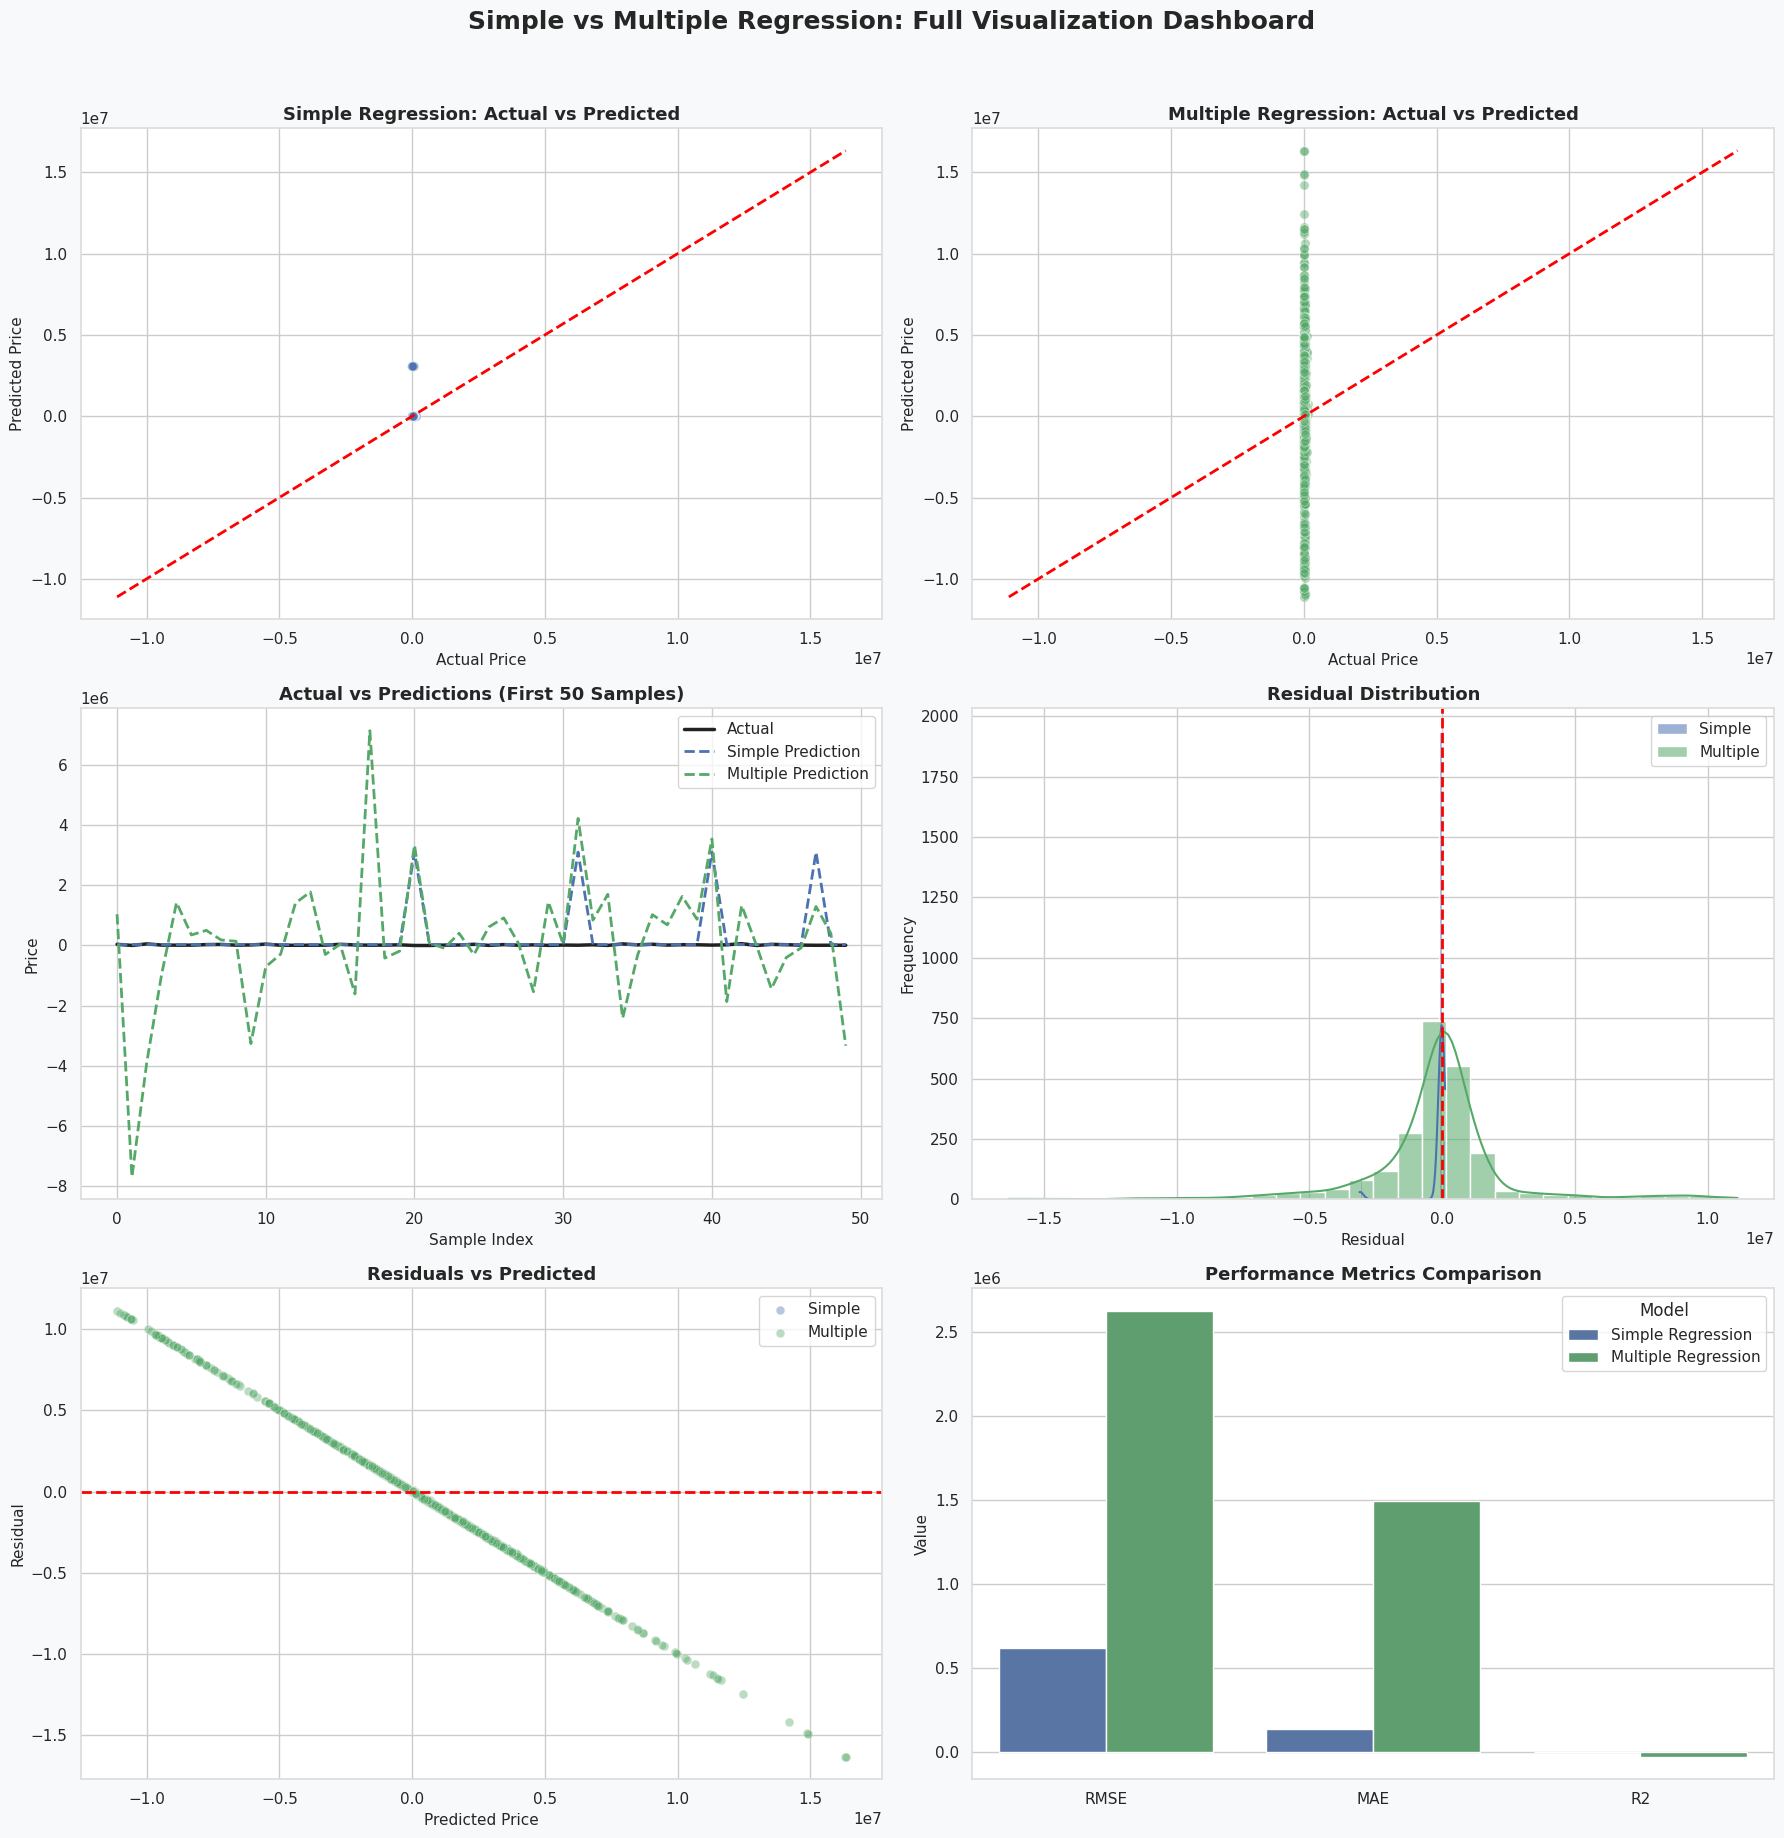

Metrics Summary
                 Model          RMSE           MAE          R2
0    Simple Regression  6.186475e+05  1.388355e+05  -1636.1138
1  Multiple Regression  2.628456e+06  1.492178e+06 -29551.4695

Sample Predictions
    Actual  Simple Prediction  Multiple Prediction  Simple Error  \
0  38990.0           32396.91           1040758.22       6593.09   
1   2500.0           32396.91          -7709543.08      29896.91   
2  52999.0           32396.91          -3886901.15      20602.09   
3  13499.0           32396.91           -952534.82      18897.91   
4  10995.0           32396.91           1431638.89      21401.91   
5  11999.0           32396.91            350534.14      20397.91   
6  29800.0           32396.91            503909.18       2596.91   
7  34998.0           32396.91            182380.26       2601.09   
8  10999.0           32396.91            141123.12      21397.91   
9  17995.0           32396.91          -3268683.12      14401.91   

   Multiple Error  
0     

<Figure size 640x480 with 0 Axes>

In [8]:
from google.colab import drive
drive.mount('/content/drive')

# Style
# ------------------------------
sns.set_theme(style="whitegrid", palette="Set2", context="notebook")
plt.rcParams["figure.facecolor"] = "#f8f9fa"
plt.rcParams["axes.facecolor"] = "#ffffff"
plt.rcParams["axes.edgecolor"] = "#dddddd"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# ------------------------------
# Data for plots
# ------------------------------
actual = np.array(y_test)
simple_pred = np.array(simple_predictions)
multiple_pred = np.array(multiple_std_predictions)

simple_residuals = actual - simple_pred
multiple_residuals = actual - multiple_pred

simple_rmse = np.sqrt(mean_squared_error(actual, simple_pred))
simple_mae = mean_absolute_error(actual, simple_pred)
simple_r2 = r2_score(actual, simple_pred)

multiple_rmse = np.sqrt(mean_squared_error(actual, multiple_pred))
multiple_mae = mean_absolute_error(actual, multiple_pred)
multiple_r2 = r2_score(actual, multiple_pred)

metrics_df = pd.DataFrame({
    "Model": ["Simple Regression", "Multiple Regression"],
    "RMSE": [simple_rmse, multiple_rmse],
    "MAE": [simple_mae, multiple_mae],
    "R2": [simple_r2, multiple_r2]
})

comparison_df = pd.DataFrame({
    "Actual": actual,
    "Simple Prediction": simple_pred,
    "Multiple Prediction": multiple_pred,
    "Simple Error": np.abs(actual - simple_pred),
    "Multiple Error": np.abs(actual - multiple_pred)
})

sample_df = comparison_df.head(50)

min_val = min(actual.min(), simple_pred.min(), multiple_pred.min())
max_val = max(actual.max(), simple_pred.max(), multiple_pred.max())

# ------------------------------
# Figure layout
# ------------------------------
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle("Simple vs Multiple Regression: Full Visualization Dashboard", fontsize=18, fontweight="bold", y=1.02)

# 1. Actual vs Predicted - Simple
sns.scatterplot(x=actual, y=simple_pred, ax=axes[0, 0], color="#4C72B0", alpha=0.45, s=45)
axes[0, 0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
axes[0, 0].set_title("Simple Regression: Actual vs Predicted")
axes[0, 0].set_xlabel("Actual Price")
axes[0, 0].set_ylabel("Predicted Price")

# 2. Actual vs Predicted - Multiple
sns.scatterplot(x=actual, y=multiple_pred, ax=axes[0, 1], color="#55A868", alpha=0.45, s=45)
axes[0, 1].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
axes[0, 1].set_title("Multiple Regression: Actual vs Predicted")
axes[0, 1].set_xlabel("Actual Price")
axes[0, 1].set_ylabel("Predicted Price")

# 3. Actual and Predictions line plot
axes[1, 0].plot(sample_df.index, sample_df["Actual"], label="Actual", color="#222222", linewidth=2.5)
axes[1, 0].plot(sample_df.index, sample_df["Simple Prediction"], label="Simple Prediction", color="#4C72B0", linestyle="--", linewidth=2)
axes[1, 0].plot(sample_df.index, sample_df["Multiple Prediction"], label="Multiple Prediction", color="#55A868", linestyle="--", linewidth=2)
axes[1, 0].set_title("Actual vs Predictions (First 50 Samples)")
axes[1, 0].set_xlabel("Sample Index")
axes[1, 0].set_ylabel("Price")
axes[1, 0].legend()

# 4. Residual distributions
sns.histplot(simple_residuals, bins=30, kde=True, ax=axes[1, 1], color="#4C72B0", alpha=0.55, label="Simple")
sns.histplot(multiple_residuals, bins=30, kde=True, ax=axes[1, 1], color="#55A868", alpha=0.55, label="Multiple")
axes[1, 1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[1, 1].set_title("Residual Distribution")
axes[1, 1].set_xlabel("Residual")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].legend()

# 5. Residual scatter plot
sns.scatterplot(x=simple_pred, y=simple_residuals, ax=axes[2, 0], color="#4C72B0", alpha=0.4, s=40, label="Simple")
sns.scatterplot(x=multiple_pred, y=multiple_residuals, ax=axes[2, 0], color="#55A868", alpha=0.4, s=40, label="Multiple")
axes[2, 0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[2, 0].set_title("Residuals vs Predicted")
axes[2, 0].set_xlabel("Predicted Price")
axes[2, 0].set_ylabel("Residual")
axes[2, 0].legend()

# 6. Metrics comparison
metrics_long = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Value")
sns.barplot(data=metrics_long, x="Metric", y="Value", hue="Model", ax=axes[2, 1], palette=["#4C72B0", "#55A868"])
axes[2, 1].set_title("Performance Metrics Comparison")
axes[2, 1].set_xlabel("")
axes[2, 1].set_ylabel("Value")
axes[2, 1].legend(title="Model")

plt.tight_layout()
plt.show()

# ------------------------------
# Printed outputs
# ------------------------------
plt.savefig("/content/drive/MyDrive/task2_regression_problem.png", dpi=150, bbox_inches="tight")
print("=" * 70)
print("Metrics Summary")
print("=" * 70)
print(metrics_df.round(4))

print("\n" + "=" * 70)
print("Sample Predictions")
print("=" * 70)
print(comparison_df.head(10).round(2))